# Import the libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.tree import plot_tree
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier
from mlxtend.plotting import plot_decision_regions

import warnings
warnings.filterwarnings('ignore')

# Create a dataset

In [3]:
X, y = make_classification(n_features=5, n_redundant=0, n_informative=5, n_clusters_per_class=1)

In [4]:
df = pd.DataFrame(X, columns=['A', 'B', 'C', 'D', 'E'])
df['target'] = y

In [5]:
df.head()

,A,B,C,D,E,target
0,-1.097029,2.202823,1.576200,0.563656,3.331683,0
1,0.684861,0.528530,1.995361,-1.105913,-2.343099,1
2,0.464304,3.706569,2.003114,2.322330,0.750841,0
3,-2.949767,-2.898568,1.470757,-1.345179,-0.391470,1
4,-0.668699,-1.389634,1.909610,-2.093190,-0.292980,1


In [6]:
df.shape

(100, 6)

# Train test split

In [7]:
X = df.drop('target', axis=1)
y = df['target']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((80, 5), (20, 5), (80,), (20,))

# Bagging Classifier

In [8]:
bagging = BaggingClassifier(max_features=2)

In [9]:
bagging.fit(X_train, y_train)

BaggingClassifier(max_features=2)

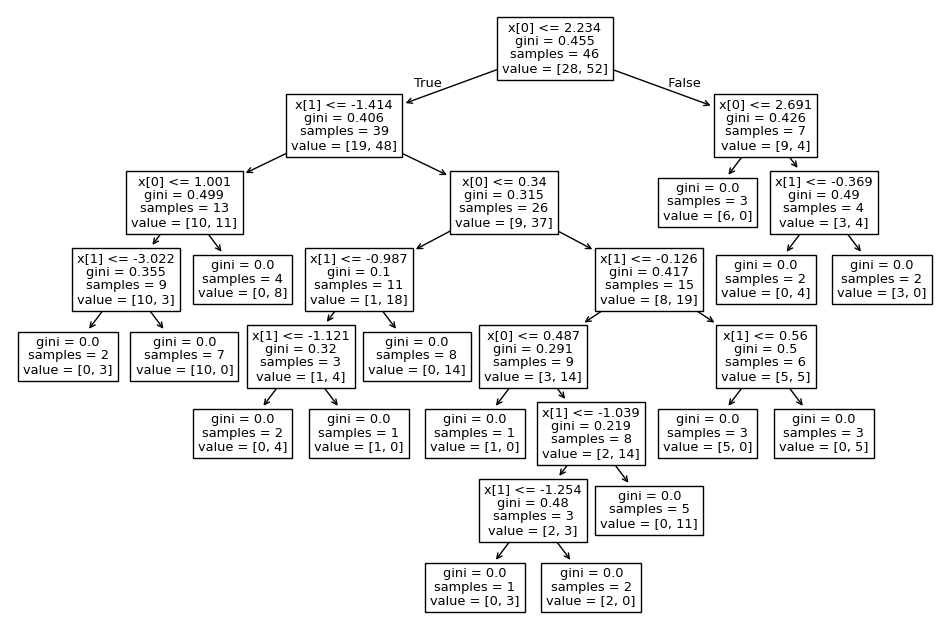

In [11]:
plt.figure(figsize=(12, 8))
plot_tree(bagging.estimators_[0])
plt.show()

* X[0], X[1] are the only two columns on which the splits happend.
* In Bagging, the feature sampling happens at tree level.

# Random Forest Classifier

In [12]:
rfc = RandomForestClassifier(max_features=2)

In [13]:
rfc.fit(X_train, y_train)

RandomForestClassifier(max_features=2)

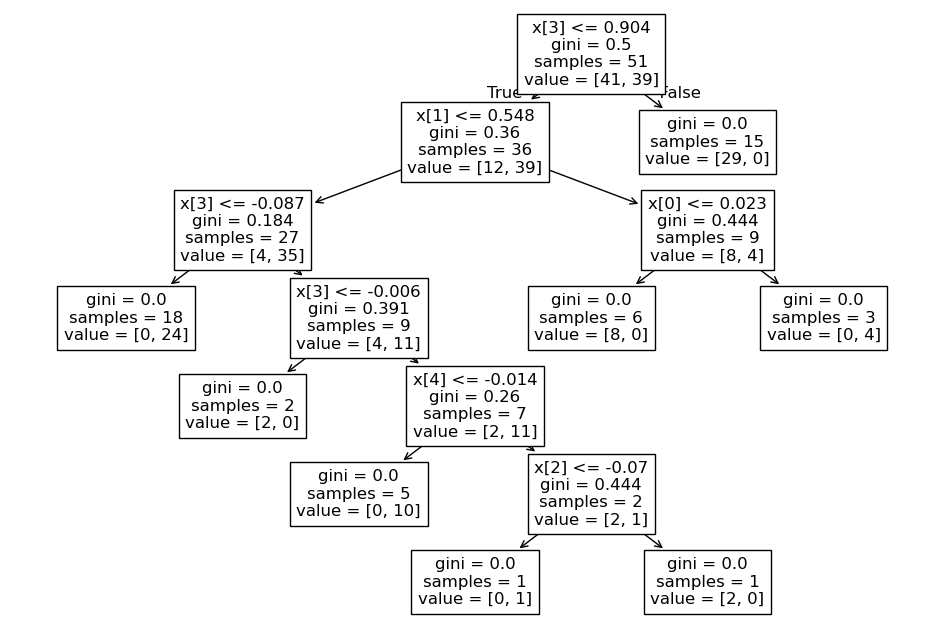

In [15]:
plt.figure(figsize=(12, 8))
plot_tree(rfc.estimators_[0])
plt.show()

* Ah, there you go, the feature sampling has happened at node level.
* Which means increased randomness => variance will be reduced.

| Aspect              | Bagging                    | Random Forest                  |
| ------------------- | -------------------------- | ------------------------------ |
| Base idea           | Bootstrap samples          | Bootstrap + feature randomness |
| Feature usage       | All features at each split | Random subset of features      |
| Tree correlation    | High                       | Low                            |
| Overfitting control | Medium                     | Strong                         |
| Default base model  | Any model                  | Decision Tree                  |
| Performance         | Good                       | Usually better                 |
